# Estatísticas do artigo (essencial)

Backup: `7_stats.ipynb.bak_full`. Default cohort âncora A = `36m_6m` · svm · vol · combat=False.

**Dois papéis (não misturar encoding):**

| Papel | Encoding | Pasta | O quê |
|-------|----------|-------|-------|
| **A · âncora metodológica** | `abs` / wide (T1+T2+T3) | `ablation_results/` | demografia, confound, abs vs t1, ComBat, clinic/fusion, leaky |
| **B · claim longitudinal** | **`t1_deltas` vs `t1_only`** | `ablation_results_deltas/` vs `ablation_results_t1_only/` | ganho temporal vs baseline |

`protocol="t1_deltas"` no código = pasta `ablation_results_deltas` = representation **`t1_deltas`** (T1 + D21/D31/D32). **Não** é `abs`.

| # | Pergunta | Papel |
|---|----------|-------|
| 1 | Idade/sexo diferem entre sMCI e pMCI? | A · demografia |
| 2 | Idade/sexo sozinhos discriminam? | A · confound |
| 3 | abs vs t1_only (FDR, 5 mods) | A · wide vs baseline (não é claim temporal) |
| 3b | ComBat vs sem (abs, FDR 5 mods) | A · sensibilidade harmonização |
| 4 | **t1_deltas vs t1_only** no primary `36m_6m` | B · exploratório (gap curto → espera Δ≈0) |
| 4b | **t1_deltas vs t1_only em `48m_12m` (5 mods, FDR; âncora vol)** | **B · teste longitudinal** |
| 5 | Clínico / imagem / fusão | A |
| 6 | abs vs leaky (global) | A · controlo |

Demografia **só no primary**. Claim longitudinal = **deltas vs baseline**, não abs vs t1.
Δ ComBat: patient-level AUC pareado; **não** redefine o primary (`combat=False`).



In [2]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

_MOD = Path.cwd() / "modules"
if str(_MOD) not in sys.path:
    sys.path.insert(0, str(_MOD))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

from ablation_analysis import (
    explode_patient_predictions,
    prepare_ablation_df,
)
from stats_compare import (
    apply_bh_fdr,
    clinical_results_path,
    compare_modalities,
    fusion_results_path,
    image_ablation_path,
    paired_comparison_row,
    print_comparison_summary,
)

BASE = Path("csvs/cohorts/36m_6m")
LONG_CSV = BASE / "adnimerged_longitudinal.csv"
MODS_COMPARE = ("vol", "shape", "texture", "disp", "all")
FEATURE_MIN_COVERAGE = 50  # % folds com atributo (paper: top estáveis)

# Pastas ↔ representation (claim B = LONGITUDINAL vs BASELINE)
PROTOCOL_ABS = "abs"              # wide T1+T2+T3 → ablation_results/
PROTOCOL_BASELINE = "t1_only"     # → ablation_results_t1_only/  (rep t1_only)
PROTOCOL_LONGITUDINAL = "t1_deltas"  # → ablation_results_deltas/   (rep t1_deltas)
REP_BY_PROTOCOL = {
    "abs": "wide",
    "t1_only": "t1_only",
    "t1_deltas": "t1_deltas",
    "deltas": "t1_deltas",  # alias legado
}


@dataclass(frozen=True)
class StatsCfg:
    task: str = "smci_pmci"
    groups: tuple[str, str] = ("sMCI", "pMCI")
    positive_group: str = "pMCI"
    modality: str = "vol"
    model_key: str = "svm"
    with_combat: bool = False
    selection_mode: str = "l1_stable"
    protocol: str = "abs"  # âncora A (§§1–2, 5–6); claim B usa PROTOCOL_* abaixo
    n_perm: int = 5000
    n_bootstrap: int = 5000
    seed: int = 42


ALPHA = 0.05  # limiar usual em artigos (5%)


def ler_p(p: float, *, contexto: str = "") -> str:
    """Texto curto para interpretar um p-value."""
    tag = "significativo" if p < ALPHA else "não significativo"
    acaso = "rejeitamos hipótese nula" if p < ALPHA else "compatível com acaso"
    prefix = f"{contexto}: " if contexto else ""
    return f"{prefix}{tag} (p={p:.4f}) — {acaso}"


STATS_CFG = StatsCfg()
print("Configuração atual:")
print(f"  base={BASE}")
print(f"  task={STATS_CFG.task}  grupos={STATS_CFG.groups}")
print(
    f"  âncora A (imagem): protocolo={STATS_CFG.protocol}  modality={STATS_CFG.modality}  "
    f"model={STATS_CFG.model_key}  combat={STATS_CFG.with_combat}"
)
print(
    f"  claim B (longitudinal): {PROTOCOL_LONGITUDINAL} (=t1_deltas) vs {PROTOCOL_BASELINE}"
)
print(f"  permutações={STATS_CFG.n_perm}  bootstrap={STATS_CFG.n_bootstrap}")



Configuração atual:
  base=csvs/cohorts/36m_6m
  task=smci_pmci  grupos=('sMCI', 'pMCI')
  âncora A (imagem): protocolo=abs  modality=vol  model=svm  combat=False
  claim B (longitudinal): deltas (=t1_deltas) vs t1_only
  permutações=5000  bootstrap=5000


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def load_cohort(long_path: Path, cfg: StatsCfg) -> pd.DataFrame:
    """Uma linha por paciente: slot baseline (legado) ou t0 (cohorts atuais)."""
    sub = pd.read_csv(long_path)
    slots = sub["slot"].astype(str)
    sub = sub[slots.isin(("baseline", "t0"))]
    sub = sub.sort_values(["ID_PT", "ID_IMG"]).groupby("ID_PT", as_index=False).first()
    sub = sub[sub["GROUP"].isin(cfg.groups)].copy()
    sub["ID_PT"] = sub["ID_PT"].astype(str)
    sub["y"] = (sub["GROUP"] == cfg.positive_group).astype(int)
    sub["SEX_bin"] = sub["SEX"].map({"M": 0, "F": 1, 0: 0, 1: 1})
    return sub


def permutation_auc_p(
    y: np.ndarray,
    scores: np.ndarray,
    *,
    n_perm: int,
    seed: int,
    bidirectional: bool = False,
) -> tuple[float, float]:
    y = np.asarray(y, dtype=int)
    s = np.asarray(scores, dtype=float)
    if bidirectional:
        auc_obs = float(max(roc_auc_score(y, s), roc_auc_score(y, -s)))
    else:
        auc_obs = float(roc_auc_score(y, s))
    prng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        yp = prng.permutation(y)
        auc_n = max(roc_auc_score(yp, s), roc_auc_score(yp, -s)) if bidirectional else roc_auc_score(yp, s)
        ge += int(auc_n >= auc_obs)
    return auc_obs, (ge + 1) / (n_perm + 1)


def bootstrap_auc_diff(y, scores_a, scores_b, *, n_boot: int, seed: int) -> tuple[float, float, float]:
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    return obs, float(ci_lo), float(ci_hi)


def bootstrap_auc_diff_test(
    y,
    scores_a,
    scores_b,
    *,
    n_boot: int,
    seed: int,
) -> tuple[float, float, float, float, float]:
    """ΔAUC = AUC(a)−AUC(b); IC95%; p one-sided (a>b) e two-sided."""
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    p_one = float((np.sum(diffs <= 0) + 1) / (len(diffs) + 1))
    p_two = float(2 * min(p_one, 1 - p_one))
    return obs, float(ci_lo), float(ci_hi), p_one, p_two


def patient_scores_for_protocol(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    return patient_image_scores(path, cfg).rename(columns={"score_img": "score"})


def nested_cv_auc_univariate(
    X: np.ndarray,
    y: np.ndarray,
    *,
    seed: int,
    k: int = 5,
) -> tuple[float, np.ndarray]:
    """LogReg + scaler em 1 atributo; AUC com predições out-of-fold."""
    X = np.asarray(X, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=seed)),
    ])
    cv = StratifiedKFold(k, shuffle=True, random_state=seed)
    scores = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    return float(roc_auc_score(y, scores)), scores


def patient_image_scores(
    path: Path,
    cfg: StatsCfg,
    *,
    expect_representation: str | None = None,
) -> pd.DataFrame:
    raw = prepare_ablation_df(pd.read_csv(path))
    mask = (
        (raw["task"] == cfg.task)
        & (raw["modality"] == cfg.modality)
        & (raw["model_key"] == cfg.model_key)
        & (raw["with_combat"] == cfg.with_combat)
        & (raw["selection_mode"] == cfg.selection_mode)
    )
    if expect_representation is not None and "representation" in raw.columns:
        mask = mask & (raw["representation"].astype(str) == expect_representation)
    sub = raw.loc[mask]
    if sub.empty:
        raise FileNotFoundError(
            f"sem linhas para {cfg}"
            + (f" representation={expect_representation}" if expect_representation else "")
            + f" em {path}"
        )
    if expect_representation is not None and "representation" in sub.columns:
        got = sorted(sub["representation"].astype(str).unique())
        if got != [expect_representation]:
            raise ValueError(f"representation inesperada em {path}: {got}")
    pat = explode_patient_predictions(sub)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score_img=("score", "mean"))


def patient_scores_from_path(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    """Infere representation esperada pela pasta do protocolo (deltas→t1_deltas)."""
    expect = None
    parts = {p.name for p in path.parents}
    if "ablation_results_deltas" in parts:
        expect = "t1_deltas"
    elif "ablation_results_t1_only" in parts:
        expect = "t1_only"
    elif "ablation_results" in parts and "ablation_results_deltas" not in parts:
        # pasta abs/wide; não confundir com *_deltas / *_t1_only (já cobertos acima)
        if not any(n.startswith("ablation_results_") for n in parts):
            expect = "wide"
    return patient_scores_for_protocol_expect(path, cfg, expect_representation=expect)


def patient_scores_for_protocol_expect(
    path: Path,
    cfg: StatsCfg,
    *,
    expect_representation: str | None,
) -> pd.DataFrame:
    return patient_image_scores(
        path, cfg, expect_representation=expect_representation
    ).rename(columns={"score_img": "score"})


def cfg_for_modality(
    mod: str,
    cfg: StatsCfg | None = None,
    *,
    with_combat: bool | None = None,
) -> StatsCfg:
    c = cfg or STATS_CFG
    return StatsCfg(
        task=c.task,
        groups=c.groups,
        positive_group=c.positive_group,
        modality=mod,
        model_key=c.model_key,
        with_combat=c.with_combat if with_combat is None else with_combat,
        selection_mode=c.selection_mode,
        protocol=c.protocol,
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
    )


def cfg_clinical(cfg: StatsCfg | None = None) -> StatsCfg:
    c = cfg or STATS_CFG
    return StatsCfg(
        task=c.task,
        groups=c.groups,
        positive_group=c.positive_group,
        modality="clinical",
        model_key=c.model_key,
        with_combat=False,
        selection_mode="none",
        protocol="clinical",
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
    )


cohort = load_cohort(LONG_CSV, STATS_CFG)
g0, g1 = STATS_CFG.groups
print(f"n={len(cohort)} | {cohort['GROUP'].value_counts().to_dict()}")

n=243 | {'sMCI': 153, 'pMCI': 90}


## 1. Idade / sexo entre grupos (âncora A · primary)


In [4]:
age_a = cohort.loc[cohort["GROUP"] == g0, "AGE"].dropna()
age_b = cohort.loc[cohort["GROUP"] == g1, "AGE"].dropna()
_, p_age_groups = stats.mannwhitneyu(age_a, age_b, alternative="two-sided")

sex_tab = pd.crosstab(cohort["GROUP"], cohort["SEX_bin"], rownames=["GROUP"], colnames=["SEX (0=M, 1=F)"])
_, p_sex_groups, _, _ = stats.chi2_contingency(sex_tab)

demo = pd.DataFrame([
    {
        "variável": "idade",
        "teste": "Mann-Whitney U",
        "grupo_a": g0,
        "valor_a": age_a.mean(),
        "o_que_e_valor": "média idade (anos)",
        "grupo_b": g1,
        "valor_b": age_b.mean(),
        "p": p_age_groups,
    },
    {
        "variável": "sexo",
        "teste": "χ²",
        "grupo_a": g0,
        "valor_a": cohort.loc[cohort["GROUP"] == g0, "SEX_bin"].mean(),
        "o_que_e_valor": "proporção mulheres (F=1)",
        "grupo_b": g1,
        "valor_b": cohort.loc[cohort["GROUP"] == g1, "SEX_bin"].mean(),
        "p": p_sex_groups,
    },
])

print("Tabela de contagens (entrada do χ²):")
display(sex_tab)
print("\nResumo (valores descritivos + p do teste):")
display(demo.round(4))

print("\n── Interpretação ──")
print(ler_p(p_age_groups, contexto="Idade"))
print(ler_p(p_sex_groups, contexto="Sexo"))
if p_age_groups >= ALPHA and p_sex_groups >= ALPHA:
    print("✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.")
else:
    print("⚠ Pelo menos uma variável difere → interpretar modelos da secção 2 com cautela.")

Tabela de contagens (entrada do χ²):


"SEX (0=M, 1=F)",0,1
GROUP,,
pMCI,51,39
sMCI,99,54



Resumo (valores descritivos + p do teste):


,variável,teste,grupo_a,valor_a,o_que_e_valor,grupo_b,valor_b,p
0,idade,Mann-Whitney U,sMCI,72.7451,média idade (anos),pMCI,74.1333,0.1358
1,sexo,χ²,sMCI,0.3529,proporção mulheres (F=1),pMCI,0.4333,0.2677



── Interpretação ──
Idade: não significativo (p=0.1358) — compatível com acaso
Sexo: não significativo (p=0.2677) — compatível com acaso
✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.


## 2. Idade ou sexo sozinhos discriminam? (âncora A)


In [5]:
cfg = STATS_CFG
pt = cohort[["ID_PT", "y", "AGE", "SEX_bin"]].dropna().copy()
y = pt["y"].to_numpy()

print("Passo A — modelo só com IDADE (nested CV + permutação)")
auc_age, scores_age = nested_cv_auc_univariate(pt["AGE"].to_numpy(), y, seed=cfg.seed)
_, p_age = permutation_auc_p(y, scores_age, n_perm=cfg.n_perm, seed=cfg.seed)
print(f"  AUC = {auc_age:.3f}  |  {ler_p(p_age)}")

print("\nPasso B — modelo só com SEXO")
auc_sex, scores_sex = nested_cv_auc_univariate(pt["SEX_bin"].to_numpy(), y, seed=cfg.seed + 1)
_, p_sex = permutation_auc_p(y, scores_sex, n_perm=cfg.n_perm, seed=cfg.seed + 1)
print(f"  AUC = {auc_sex:.3f}  |  {ler_p(p_sex)}")

pt = pt.assign(score_age=scores_age, score_sex=scores_sex)

print(f"\nPasso C — scores de IMAGEM ({cfg.protocol} / {cfg.modality})")
results_path = image_ablation_path(BASE, cfg.protocol, cfg.modality)
img = patient_image_scores(results_path, cfg).merge(pt, on=["ID_PT", "y"], how="inner")
y_m = img["y"].to_numpy()

auc_img, p_img = permutation_auc_p(
    y_m, img["score_img"].to_numpy(), n_perm=cfg.n_perm, seed=cfg.seed + 2,
)
print(f"  AUC = {auc_img:.3f}  |  {ler_p(p_img)}  |  n pacientes = {len(img)}")

print("\nPasso D — imagem melhor que demografia? (bootstrap do ΔAUC)")
d_age, ci_age_lo, ci_age_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_age"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 3,
)
d_sex, ci_sex_lo, ci_sex_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_sex"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 4,
)
print(f"  ΔAUC (imagem − idade) = {d_age:.3f}  IC95% [{ci_age_lo:.3f}, {ci_age_hi:.3f}]")
print(f"  ΔAUC (imagem − sexo)  = {d_sex:.3f}  IC95% [{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]")

summary = pd.DataFrame([
    {"modelo": "só idade", "features": "AGE", "auc": auc_age, "p_permutation": p_age},
    {"modelo": "só sexo", "features": "SEX_bin", "auc": auc_sex, "p_permutation": p_sex},
    {"modelo": f"imagem ({cfg.protocol})", "features": cfg.modality, "auc": auc_img, "p_permutation": p_img},
    {"modelo": "imagem − idade", "features": "ΔAUC", "auc": d_age, "p_permutation": np.nan},
    {"modelo": "imagem − sexo", "features": "ΔAUC", "auc": d_sex, "p_permutation": np.nan},
])
summary["ci95"] = ["", "", "", f"[{ci_age_lo:.3f}, {ci_age_hi:.3f}]", f"[{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]"]
summary["confunde"] = [
    bool(auc_age > 0.55 and p_age < ALPHA),
    bool(auc_sex > 0.55 and p_sex < ALPHA),
    False,
    np.nan,
    np.nan,
]
summary["imagem_superior"] = [np.nan, np.nan, np.nan, ci_age_lo > 0, ci_sex_lo > 0]

print("\n── Tabela resumo ──")
display(summary.round(4))

print("\n── Conclusão automática ──")
if not summary.loc[0, "confunde"] and not summary.loc[1, "confunde"]:
    print("• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.")
else:
    print("• Atenção: idade ou sexo mostram sinal discriminativo → interpretar imagem com cuidado.")

if p_img < ALPHA and auc_img > 0.55:
    print(f"• Imagem ({cfg.protocol}) discrimina significativamente (AUC ≈ {auc_img:.2f}).")
if ci_age_lo > 0:
    print(f"• Imagem supera idade: ganho médio ΔAUC ≈ {d_age:.2f} (IC95% não cruza zero).")
if ci_sex_lo > 0:
    print(f"• Imagem supera sexo: ganho médio ΔAUC ≈ {d_sex:.2f} (IC95% não cruza zero).")



Passo A — modelo só com IDADE (nested CV + permutação)
  AUC = 0.553  |  não significativo (p=0.0884) — compatível com acaso

Passo B — modelo só com SEXO
  AUC = 0.509  |  não significativo (p=0.4041) — compatível com acaso

Passo C — scores de IMAGEM (abs / vol)
  AUC = 0.715  |  significativo (p=0.0002) — rejeitamos hipótese nula  |  n pacientes = 243

Passo D — imagem melhor que demografia? (bootstrap do ΔAUC)
  ΔAUC (imagem − idade) = 0.162  IC95% [0.079, 0.244]
  ΔAUC (imagem − sexo)  = 0.206  IC95% [0.096, 0.313]

── Tabela resumo ──


,modelo,features,auc,p_permutation,ci95,confunde,imagem_superior
0,só idade,AGE,0.5525,0.0884,,False,NaN
1,só sexo,SEX_bin,0.5086,0.4041,,False,NaN
2,imagem (abs),vol,0.7145,0.0002,,False,NaN
3,imagem − idade,ΔAUC,0.1620,NaN,"[0.079, 0.244]",NaN,True
4,imagem − sexo,ΔAUC,0.2059,NaN,"[0.096, 0.313]",NaN,True



── Conclusão automática ──
• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.
• Imagem (abs) discrimina significativamente (AUC ≈ 0.71).
• Imagem supera idade: ganho médio ΔAUC ≈ 0.16 (IC95% não cruza zero).
• Imagem supera sexo: ganho médio ΔAUC ≈ 0.21 (IC95% não cruza zero).


## 3. abs vs t1_only — âncora A (wide vs baseline · FDR)

Compara **wide** (`abs` = T1+T2+T3 absolutos) vs baseline (`t1_only`) no primary.

Isto **não** é o claim longitudinal. Claim temporal = **t1_deltas vs t1_only** (§§4–4b).


In [6]:
cfg = STATS_CFG

cmp_abs_t1 = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "t1_only", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed,
    label_a="abs",
    label_b="t1_only",
    comparison="abs_vs_t1_only",
    alpha=ALPHA,
)
print(
    f"Âncora A · teste formal | abs vs t1_only | {cfg.task} | {cfg.model_key} | "
    f"combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_abs_t1.round(4))
print("\n── Interpretação (ΔAUC = abs − t1_only) ──")
print_comparison_summary(cmp_abs_t1, label_a="abs", label_b="t1_only")


Âncora A · teste formal | abs vs t1_only | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_abs,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,243,0.7145,0.7275,-0.0129,-0.0547,0.0275,0.7265,0.5471,False,0.0002,0.0002,False,False,vol,abs_vs_t1_only,0.9676
1,243,0.7675,0.7859,-0.0184,-0.0390,0.0012,0.9676,0.0648,False,0.0002,0.0002,False,False,shape,abs_vs_t1_only,0.9676
2,243,0.7573,0.7081,0.0492,0.0028,0.0947,0.0190,0.0380,True,0.0002,0.0002,False,True,texture,abs_vs_t1_only,0.0950
3,243,0.5582,0.6479,-0.0897,-0.1903,0.0080,0.9628,0.0744,False,0.0650,0.0002,False,False,disp,abs_vs_t1_only,0.9676
4,243,0.7594,0.7467,0.0127,-0.0381,0.0620,0.2987,0.5975,False,0.0002,0.0002,False,False,all,abs_vs_t1_only,0.7469



── Interpretação (ΔAUC = abs − t1_only) ──
  vol: ΔAUC=-0.013 [-0.055, 0.027]  p=0.7265  q=0.9676  → sem evidência
  shape: ΔAUC=-0.018 [-0.039, 0.001]  p=0.9676  q=0.9676  → sem evidência
  texture: ΔAUC=0.049 [0.003, 0.095]  p=0.0190  q=0.0950  → raw sig.
  disp: ΔAUC=-0.090 [-0.190, 0.008]  p=0.9628  q=0.9676  → sem evidência
  all: ΔAUC=0.013 [-0.038, 0.062]  p=0.2987  q=0.7469  → sem evidência


## 3b. ComBat vs sem ComBat — sensibilidade (âncora A)

Mesmo protocolo **abs/wide**, mesmo modelo; só muda `with_combat`.  
ΔAUC = **nocombat − combat** (positivo ⇒ ComBat piora). Bootstrap pareado + FDR nas 5 modalidades.

Sensibilidade — **não** substitui o primary pré-especificado (`combat=False`).

In [7]:
cfg = STATS_CFG

# Δ = nocombat − combat; H1 one-sided: nocombat > combat (ComBat piora)
cmp_combat = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "abs", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg, with_combat=False),
    cfg_for_mod_b=lambda m: cfg_for_modality(m, cfg, with_combat=True),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed + 300,
    label_a="nocombat",
    label_b="combat",
    comparison="nocombat_vs_combat_abs",
    alpha=ALPHA,
)

print(
    f"Âncora A · sensibilidade | ComBat vs sem | abs | {cfg.task} | {cfg.model_key} | "
    f"{cfg.selection_mode}\n"
    f"ΔAUC = nocombat − combat  (positivo ⇒ ComBat piora)\n"
)
display(cmp_combat.round(4))
print("\n── Interpretação (5 mods, FDR) ──")
print_comparison_summary(cmp_combat, label_a="nocombat", label_b="combat")

# Destaque primary (vol)
if not cmp_combat.empty and (cmp_combat["modality"] == "vol").any():
    r = cmp_combat.loc[cmp_combat["modality"] == "vol"].iloc[0]
    print("\n── PRIMARY vol / svm ──")
    print(
        f"  AUC nocombat = {r['auc_nocombat']:.3f}   AUC combat = {r['auc_combat']:.3f}"
    )
    print(
        f"  ΔAUC = {r['delta_auc']:.3f}   IC95% [{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]"
    )
    print(
        f"  p one-sided (nocombat>combat) = {r['p_bootstrap_one_sided']:.4f}   "
        f"p two-sided = {r['p_bootstrap_two_sided']:.4f}   "
        f"q FDR = {r['p_fdr_bh']:.4f}"
    )
    if r["ci95_lo"] > 0 and r["p_fdr_bh"] < ALPHA:
        print("  → ComBat piora de forma significativa (IC>0 e FDR).")
    elif r["ci95_hi"] < 0 and r["p_bootstrap_two_sided"] < ALPHA:
        print("  → ComBat melhora (inesperado face ao ponto descritivo).")
    elif r["delta_auc"] > 0 and r["ci95_lo"] <= 0:
        print(
            "  → Ponto: ComBat piora, mas IC cruza 0 — sem evidência formal de piora "
            "(não é equivalência; primary permanece sem ComBat)."
        )
    else:
        print("  → Sem evidência clara de diferença; primary permanece sem ComBat.")
else:
    print("\n(sem linha vol em cmp_combat — verificar ablation_results/vol/)")


Âncora A · sensibilidade | ComBat vs sem | abs | smci_pmci | svm | l1_stable
ΔAUC = nocombat − combat  (positivo ⇒ ComBat piora)



,n_pacientes,auc_nocombat,auc_combat,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,nocombat_superior,p_perm_nocombat,p_perm_combat,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,243,0.7145,0.6925,0.0220,-0.0071,0.0504,0.0664,0.1328,False,0.0002,0.0002,False,False,vol,nocombat_vs_combat_abs,0.3319
1,243,0.7675,0.7527,0.0147,-0.0132,0.0436,0.1462,0.2923,False,0.0002,0.0002,False,False,shape,nocombat_vs_combat_abs,0.3654
2,243,0.7573,0.7662,-0.0089,-0.0414,0.0240,0.6949,0.6103,False,0.0002,0.0002,False,False,texture,nocombat_vs_combat_abs,0.6949
3,243,0.5582,0.5561,0.0022,-0.0568,0.0614,0.4811,0.9622,False,0.0722,0.0768,False,False,disp,nocombat_vs_combat_abs,0.6949
4,243,0.7594,0.7639,-0.0045,-0.0347,0.0268,0.6185,0.7630,False,0.0002,0.0002,False,False,all,nocombat_vs_combat_abs,0.6949



── Interpretação (5 mods, FDR) ──
  vol: ΔAUC=0.022 [-0.007, 0.050]  p=0.0664  q=0.3319  → sem evidência
  shape: ΔAUC=0.015 [-0.013, 0.044]  p=0.1462  q=0.3654  → sem evidência
  texture: ΔAUC=-0.009 [-0.041, 0.024]  p=0.6949  q=0.6949  → sem evidência
  disp: ΔAUC=0.002 [-0.057, 0.061]  p=0.4811  q=0.6949  → sem evidência
  all: ΔAUC=-0.005 [-0.035, 0.027]  p=0.6185  q=0.6949  → sem evidência

── PRIMARY vol / svm ──
  AUC nocombat = 0.715   AUC combat = 0.693
  ΔAUC = 0.022   IC95% [-0.007, 0.050]
  p one-sided (nocombat>combat) = 0.0664   p two-sided = 0.1328   q FDR = 0.3319
  → Ponto: ComBat piora, mas IC cruza 0 — sem evidência formal de piora (não é equivalência; primary permanece sem ComBat).


## 4. t1_deltas vs t1_only — exploratório no primary (claim B)

Contraste **longitudinal vs baseline**: pasta `ablation_results_deltas` (representation `t1_deltas`) vs `ablation_results_t1_only`.

No primary (`36m_6m`, gap curto) espera-se Δ≈0 (deltas ≈ t1). **Não** crownear ganho aqui.

Claim com janela longa → **§4b** (`48m_12m` · vol).  
`abs`/wide **não** entra neste contraste (abs vs t1 = §3, papel A).


In [8]:
cfg = STATS_CFG

# Claim B: t1_deltas (PROTOCOL_LONGITUDINAL) vs t1_only (PROTOCOL_BASELINE)
cmp_deltas_t1 = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, PROTOCOL_LONGITUDINAL, m),
    path_b=lambda m: image_ablation_path(BASE, PROTOCOL_BASELINE, m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed,
    label_a="t1_deltas",
    label_b="t1_only",
    comparison="t1_deltas_vs_t1_only",
    alpha=ALPHA,
)
print(
    f"Claim B · exploratório | t1_deltas vs t1_only | {BASE.name} | {cfg.task} | "
    f"{cfg.model_key} | combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_deltas_t1.round(4))
print("\n── Interpretação (ΔAUC = t1_deltas − t1_only) ──")
print_comparison_summary(cmp_deltas_t1, label_a="t1_deltas", label_b="t1_only")



Claim B · exploratório | t1_deltas vs t1_only | 36m_6m | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_t1_deltas,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,t1_deltas_superior,p_perm_t1_deltas,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,243,0.7181,0.7275,-0.0094,-0.0499,0.0293,0.6803,0.6395,False,0.0002,0.0002,False,False,vol,t1_deltas_vs_t1_only,0.9726
1,243,0.7664,0.7859,-0.0195,-0.0404,0.0006,0.9726,0.0548,False,0.0002,0.0002,False,False,shape,t1_deltas_vs_t1_only,0.9726
2,243,0.7566,0.7081,0.0485,-0.0009,0.0975,0.0272,0.0544,False,0.0002,0.0002,False,False,texture,t1_deltas_vs_t1_only,0.1360
3,243,0.5805,0.6479,-0.0674,-0.1474,0.0146,0.9478,0.1044,False,0.0156,0.0002,False,False,disp,t1_deltas_vs_t1_only,0.9726
4,243,0.7590,0.7467,0.0123,-0.0433,0.0672,0.3299,0.6599,False,0.0002,0.0002,False,False,all,t1_deltas_vs_t1_only,0.8248



── Interpretação (ΔAUC = t1_deltas − t1_only) ──
  vol: ΔAUC=-0.009 [-0.050, 0.029]  p=0.6803  q=0.9726  → sem evidência
  shape: ΔAUC=-0.020 [-0.040, 0.001]  p=0.9726  q=0.9726  → sem evidência
  texture: ΔAUC=0.049 [-0.001, 0.098]  p=0.0272  q=0.1360  → sem evidência
  disp: ΔAUC=-0.067 [-0.147, 0.015]  p=0.9478  q=0.9726  → sem evidência
  all: ΔAUC=0.012 [-0.043, 0.067]  p=0.3299  q=0.8248  → sem evidência


## 4b. t1_deltas vs t1_only — `48m_12m` (todas as modalidades)

**Claim B:** temporal encoding (`t1_deltas`) vs baseline (`t1_only`) na janela longa.

**Desenho:**
- pastas: `ablation_results_deltas/` (= `t1_deltas`) vs `ablation_results_t1_only/`
- mesmos pacientes em `csvs/cohorts/48m_12m`
- modalidades: `vol`, `shape`, `texture`, `disp`, `all` (FDR Benjamini–Hochberg nos 5 testes)
- âncora de interpretação / crowning: **vol** (pré-acordada); demais = mapa de ganho condicional
- H1 one-sided: AUC(t1_deltas) > AUC(t1_only); superioridade repo: `ci95_lo > 0` e p₁ < α (e q FDR < α para crownear multi-mod)

Seleção de cohort após gradiente multi-cohort → **pós-hoc no recorte**; não crownear shape/texture/disp/all como primary só porque FDR passou.


In [9]:
BASE_48 = Path("csvs/cohorts/48m_12m")
cfg = STATS_CFG
mod_anchor = cfg.modality  # âncora de crowning: vol

# sanity: pastas e representation (vol como exemplo)
_p_long = image_ablation_path(BASE_48, PROTOCOL_LONGITUDINAL, mod_anchor)
_p_base = image_ablation_path(BASE_48, PROTOCOL_BASELINE, mod_anchor)
print(f"longitudinal: {_p_long.parent.parent.name}/{{mod}}/  (expect rep={REP_BY_PROTOCOL[PROTOCOL_LONGITUDINAL]})")
print(f"baseline:     {_p_base.parent.parent.name}/{{mod}}/  (expect rep={REP_BY_PROTOCOL[PROTOCOL_BASELINE]})")
print(f"modalidades: {MODS_COMPARE}  | âncora crowning: {mod_anchor}")

cmp_48_deltas_t1 = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE_48, PROTOCOL_LONGITUDINAL, m),
    path_b=lambda m: image_ablation_path(BASE_48, PROTOCOL_BASELINE, m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed,
    label_a="t1_deltas",
    label_b="t1_only",
    comparison="48m_12m_t1_deltas_vs_t1_only",
    alpha=ALPHA,
)

print(
    f"\nClaim B | 48m_12m | t1_deltas vs t1_only | {cfg.task} | "
    f"{cfg.model_key} | combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_48_deltas_t1.round(4))
print("\n── Interpretação (ΔAUC = t1_deltas − t1_only; FDR nas 5 mods) ──")
print_comparison_summary(cmp_48_deltas_t1, label_a="t1_deltas", label_b="t1_only")

# Destaque âncora vol
if not cmp_48_deltas_t1.empty and (cmp_48_deltas_t1["modality"] == mod_anchor).any():
    r = cmp_48_deltas_t1.loc[cmp_48_deltas_t1["modality"] == mod_anchor].iloc[0]
    print(f"\n── Resumo âncora {mod_anchor} ──")
    print(
        f"  n={int(r['n_pacientes'])}  "
        f"AUC_t1_deltas={r['auc_t1_deltas']:.4f}  AUC_t1={r['auc_t1_only']:.4f}  "
        f"Δ={r['delta_auc']:.4f}  IC95=[{r['ci95_lo']:.4f}, {r['ci95_hi']:.4f}]"
    )
    print(
        f"  p one-sided={r['p_bootstrap_one_sided']:.4f}  "
        f"p two-sided={r['p_bootstrap_two_sided']:.4f}  "
        f"q FDR={r['p_fdr_bh']:.4f}  "
        f"t1_deltas_superior={r['t1_deltas_superior']}  "
        f"significant_raw={r['significant_raw']}  significant_fdr={r['significant_fdr']}"
    )
    if r["significant_fdr"]:
        print("  → superioridade com FDR (IC>0 e q<α) — crowning ok no mapa multi-mod.")
    elif r["t1_deltas_superior"] and r["significant_raw"]:
        print(
            "  → superioridade raw (IC>0 e p₁<α), mas FDR não passa "
            "→ reportar como âncora pré-especificada, não como família fechada."
        )
    elif r["p_bootstrap_one_sided"] < ALPHA:
        print(
            "  → ganho nominal one-sided, mas IC cruza 0 "
            "→ NÃO crownear como superioridade fechada."
        )
    else:
        print("  → sem evidência de superioridade (t1_deltas > t1_only) na âncora vol.")

# Mapa: quais mods passam FDR / raw
if not cmp_48_deltas_t1.empty:
    print("\n── Mapa multi-mod (claim condicional) ──")
    for _, r in cmp_48_deltas_t1.iterrows():
        tag = (
            "FDR+" if r["significant_fdr"] else
            ("raw+" if r["significant_raw"] else "n.s.")
        )
        print(
            f"  {r['modality']}: Δ={r['delta_auc']:+.3f}  "
            f"[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]  "
            f"p={r['p_bootstrap_one_sided']:.4f}  q={r['p_fdr_bh']:.4f}  → {tag}"
        )


longitudinal: ablation_results_deltas/{mod}/  (expect rep=t1_deltas)
baseline:     ablation_results_t1_only/{mod}/  (expect rep=t1_only)
modalidades: ('vol', 'shape', 'texture', 'disp', 'all')  | âncora crowning: vol

Claim B | 48m_12m | t1_deltas vs t1_only | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_t1_deltas,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,t1_deltas_superior,p_perm_t1_deltas,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,111,0.7310,0.6384,0.0926,-0.0269,0.2076,0.0588,0.1176,False,0.0002,0.0078,False,False,vol,48m_12m_t1_deltas_vs_t1_only,0.0980
1,111,0.7870,0.7856,0.0014,-0.0654,0.0694,0.4773,0.9546,False,0.0002,0.0002,False,False,shape,48m_12m_t1_deltas_vs_t1_only,0.5966
2,111,0.7437,0.6373,0.1063,0.0084,0.2021,0.0154,0.0308,True,0.0002,0.0088,False,True,texture,48m_12m_t1_deltas_vs_t1_only,0.0770
3,111,0.6109,0.4687,0.1423,-0.0373,0.3140,0.0558,0.1116,False,0.0274,0.7109,False,False,disp,48m_12m_t1_deltas_vs_t1_only,0.0980
4,111,0.7493,0.7817,-0.0324,-0.1197,0.0479,0.7750,0.4499,False,0.0002,0.0002,False,False,all,48m_12m_t1_deltas_vs_t1_only,0.7750



── Interpretação (ΔAUC = t1_deltas − t1_only; FDR nas 5 mods) ──
  vol: ΔAUC=0.093 [-0.027, 0.208]  p=0.0588  q=0.0980  → sem evidência
  shape: ΔAUC=0.001 [-0.065, 0.069]  p=0.4773  q=0.5966  → sem evidência
  texture: ΔAUC=0.106 [0.008, 0.202]  p=0.0154  q=0.0770  → raw sig.
  disp: ΔAUC=0.142 [-0.037, 0.314]  p=0.0558  q=0.0980  → sem evidência
  all: ΔAUC=-0.032 [-0.120, 0.048]  p=0.7750  q=0.7750  → sem evidência

── Resumo âncora vol ──
  n=111  AUC_t1_deltas=0.7310  AUC_t1=0.6384  Δ=0.0926  IC95=[-0.0269, 0.2076]
  p one-sided=0.0588  p two-sided=0.1176  q FDR=0.0980  t1_deltas_superior=False  significant_raw=False  significant_fdr=False
  → sem evidência de superioridade (t1_deltas > t1_only) na âncora vol.

── Mapa multi-mod (claim condicional) ──
  vol: Δ=+0.093  [-0.027, 0.208]  p=0.0588  q=0.0980  → n.s.
  shape: Δ=+0.001  [-0.065, 0.069]  p=0.4773  q=0.5966  → n.s.
  texture: Δ=+0.106  [0.008, 0.202]  p=0.0154  q=0.0770  → raw+
  disp: Δ=+0.142  [-0.037, 0.314]  p=0.0558 

## 5. Clínico vs imagem vs fusão (âncora A)


Clínico / imagem / fusão | smci_pmci | mod=vol | svm



,n_pacientes,auc_img,auc_clin,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,img_superior,p_perm_img,p_perm_clin,significant_fdr,significant_raw,modality,comparison,auc_fusion,fusion_superior,p_perm_fusion,p_fdr_bh
0,243,0.7145,0.8551,-0.1406,-0.2241,-0.0622,1.0000,0.0000,False,0.0002,0.0002,False,False,vol,image_abs_vs_clinical,NaN,NaN,NaN,1.0000
1,243,NaN,0.8551,0.0110,-0.0213,0.0447,0.2468,0.4935,NaN,NaN,0.0002,False,False,vol,fusion_vs_clinical,0.8662,False,0.0002,0.3701
2,243,0.7145,NaN,0.1516,0.0939,0.2123,0.0002,0.0004,NaN,0.0002,NaN,True,True,vol,fusion_vs_image_abs,0.8662,True,0.0002,0.0006



── Interpretação ──
  image_abs_vs_clinical: ΔAUC=-0.141 [-0.224, -0.062]  p=1.0000
  fusion_vs_clinical: ΔAUC=0.011 [-0.021, 0.045]  p=0.2468
  fusion_vs_image_abs: ΔAUC=0.152 [0.094, 0.212]  p=0.0002


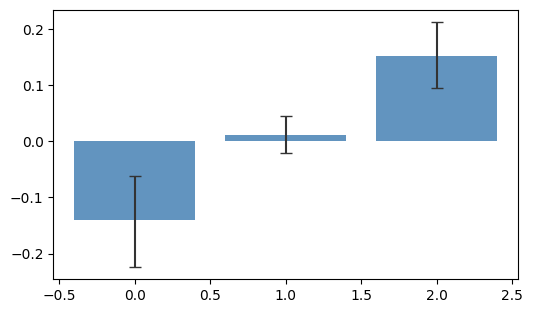

In [19]:
cfg = STATS_CFG
mod = cfg.modality
img_cfg = cfg_for_modality(mod, cfg)
clin_cfg = cfg_clinical(cfg)
fusion_path = fusion_results_path(
    BASE, mod, selection_mode=cfg.selection_mode, with_combat=cfg.with_combat,
)
clin_path = clinical_results_path(BASE)
img_path = image_ablation_path(BASE, "abs", mod)

clinical_rows: list[dict] = []
if img_path.exists() and clin_path.exists():
    paired = patient_scores_from_path(img_path, img_cfg).merge(
        patient_scores_from_path(clin_path, clin_cfg),
        on=["ID_PT", "y"],
        suffixes=("_img", "_clin"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_img",
        score_b="score_clin",
        label_a="img",
        label_b="clin",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 200,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "image_abs_vs_clinical"})
    clinical_rows.append(row)

if fusion_path.exists() and clin_path.exists():
    paired = patient_scores_from_path(fusion_path, img_cfg).merge(
        patient_scores_from_path(clin_path, clin_cfg),
        on=["ID_PT", "y"],
        suffixes=("_fusion", "_clin"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_fusion",
        score_b="score_clin",
        label_a="fusion",
        label_b="clin",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 201,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "fusion_vs_clinical"})
    clinical_rows.append(row)

if fusion_path.exists() and img_path.exists():
    paired = patient_scores_from_path(fusion_path, img_cfg).merge(
        patient_scores_from_path(img_path, img_cfg),
        on=["ID_PT", "y"],
        suffixes=("_fusion", "_img"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_fusion",
        score_b="score_img",
        label_a="fusion",
        label_b="img",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 202,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "fusion_vs_image_abs"})
    clinical_rows.append(row)

cmp_clinical = pd.DataFrame(clinical_rows)
if not cmp_clinical.empty:
    cmp_clinical["p_fdr_bh"] = apply_bh_fdr(cmp_clinical["p_bootstrap_one_sided"].to_numpy())
    cmp_clinical["significant_fdr"] = (
        cmp_clinical["p_fdr_bh"] < ALPHA
    ) & (cmp_clinical["ci95_lo"] > 0)

print(f"Clínico / imagem / fusão | {cfg.task} | mod={mod} | {cfg.model_key}\n")
display(cmp_clinical.round(4))

print("\n── Interpretação ──")
for _, r in cmp_clinical.iterrows():
    print(
        f"  {r['comparison']}: ΔAUC={r['delta_auc']:.3f} "
        f"[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]  p={r['p_bootstrap_one_sided']:.4f}"
    )

if not cmp_clinical.empty:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    labels = cmp_clinical["comparison"].str.replace("_", " ", regex=False)
    x = np.arange(len(cmp_clinical))
    ax.bar(x, cmp_clinical["delta_auc"], color="steelblue", alpha=0.85)
    ax.errorbar(
        x,
        cmp_clinical["delta_auc"],
        yerr=[
            cmp_clinical["delta_auc"] - cmp_clinical["ci95_lo"],
            cmp_clinical["ci95_hi"] - cmp_clinical["delta_auc"],
        ],
        fmt="none",
        color="0.2",
        capsize=4,
    )


## 6. abs vs global / leaky (âncora A · controlo)


In [20]:
cfg = STATS_CFG

cmp_abs_global = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "global", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed + 100,
    label_a="abs",
    label_b="global",
    comparison="abs_vs_global",
    alpha=ALPHA,
)
print(f"abs vs global (leaky) | {cfg.task} | {cfg.model_key}\n")
display(cmp_abs_global.round(4))
print("\n── Interpretação (ΔAUC = abs − global; negativo → leaky maior) ──")
print_comparison_summary(cmp_abs_global, label_a="abs", label_b="global")

abs vs global (leaky) | smci_pmci | svm



,n_pacientes,auc_abs,auc_global,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_global,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,243,0.7145,0.7299,-0.0154,-0.0441,0.0139,0.8498,0.3003,False,0.0002,0.0002,False,False,vol,abs_vs_global,0.9992
1,243,0.7675,0.7864,-0.0190,-0.0317,-0.0065,0.9992,0.0016,False,0.0002,0.0002,False,False,shape,abs_vs_global,0.9992
2,243,0.7573,0.7582,-0.0009,-0.0079,0.0058,0.6039,0.7922,False,0.0002,0.0002,False,False,texture,abs_vs_global,0.9992
3,243,0.5582,0.5513,0.0070,-0.0578,0.0701,0.4127,0.8254,False,0.0686,0.0990,False,False,disp,abs_vs_global,0.9992
4,243,0.7594,0.8118,-0.0524,-0.1011,-0.0051,0.9856,0.0288,False,0.0002,0.0002,False,False,all,abs_vs_global,0.9992



── Interpretação (ΔAUC = abs − global; negativo → leaky maior) ──
  vol: ΔAUC=-0.015 [-0.044, 0.014]  p=0.8498  q=0.9992  → sem evidência
  shape: ΔAUC=-0.019 [-0.032, -0.007]  p=0.9992  q=0.9992  → sem evidência
  texture: ΔAUC=-0.001 [-0.008, 0.006]  p=0.6039  q=0.9992  → sem evidência
  disp: ΔAUC=0.007 [-0.058, 0.070]  p=0.4127  q=0.9992  → sem evidência
  all: ΔAUC=-0.052 [-0.101, -0.005]  p=0.9856  q=0.9992  → sem evidência
